# 04 — Feature Engineering & Exploratory Analysis

Generates behavioral, time-based, and geographic features from the cleaned
dataset, then explores how they differ between fraudulent and legitimate transactions.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv(r'C:\Users\Opeyemi\OneDrive - UNC Kenan-Flagler Business School\Desktop\Data Science\Fraudulent-Transaction-Detection-for-Digital-Money-Transfer/data/cleaned_transactions.csv')

In [12]:
df['timestamp'] = pd.to_datetime(df['timestamp'])



In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10650 entries, 0 to 10649
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   transaction_id             10650 non-null  str           
 1   customer_id                10650 non-null  str           
 2   timestamp                  10650 non-null  datetime64[us]
 3   home_country               10650 non-null  str           
 4   source_currency            10650 non-null  str           
 5   dest_currency              10650 non-null  str           
 6   channel                    10650 non-null  str           
 7   amount_src                 10650 non-null  float64       
 8   amount_usd                 10650 non-null  float64       
 9   fee                        10650 non-null  float64       
 10  exchange_rate_src_to_dest  10650 non-null  float64       
 11  device_id                  10650 non-null  str           
 12  new_device     

In [15]:
df.dropna(inplace=True)

In [ ]:
df['hour_of_day'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.day_name()
df['is_weekend'] = df['timestamp'].dt.weekday >= 5
df['is_night'] = df['hour_of_day'].isin([0,1,2,3,4,5])
df[['hour_of_day', 'day_of_week', 'is_weekend', 'is_night']].head()

In [17]:
df['hour_of_day'] = df['timestamp'].dt.hour

In [18]:
df['day_of_week'] = df['timestamp'].dt.day_name()

In [19]:
df['is_weekend'] = df['timestamp'].dt.weekday >= 5

In [20]:
df['is_night'] = df['hour_of_day'].isin([0,1,2,3,4,5])

In [22]:
df[['hour_of_day', 'day_of_week', 'is_weekend', 'is_night']].head()

,hour_of_day,day_of_week,is_weekend,is_night
0,18,Monday,False,False
1,20,Monday,False,False
2,23,Monday,False,False
3,1,Tuesday,False,True
4,9,Tuesday,False,False


In [23]:
df['corridor'] = df['source_currency'] + '_to_' + df['dest_currency']


In [24]:
df['corridor'].value_counts()

corridor
USD_to_NGN    960
USD_to_PHP    897
USD_to_USD    880
USD_to_CNY    870
USD_to_EUR    863
USD_to_GBP    859
USD_to_CAD    841
USD_to_INR    838
USD_to_MXN    468
GBP_to_NGN    302
GBP_to_CNY    239
GBP_to_USD    226
GBP_to_GBP    223
GBP_to_INR    223
GBP_to_PHP    219
GBP_to_MXN    216
GBP_to_CAD    207
CAD_to_INR    175
CAD_to_CAD    143
CAD_to_CNY    133
GBP_to_EUR    126
CAD_to_USD    125
CAD_to_MXN    124
CAD_to_EUR    120
CAD_to_GBP    119
CAD_to_NGN    117
CAD_to_PHP    109
Name: count, dtype: int64

In [26]:
customer_stats = df.groupby('customer_id').agg(
    customer_txn_count=('transaction_id', 'count'),
    customer_avg_amount=('amount_usd', 'mean'),
    customer_total_amount=('amount_usd', 'sum')
).reset_index()



In [29]:
customer_stats.head()


,customer_id,customer_txn_count,customer_avg_amount,customer_total_amount
0,0006f893-10a8-4235-831b-fcae1e3f0140,1,540.09,540.09
1,00147b79-11ed-4f8f-a3af-651778b78dd3,1,286.04,286.04
2,00668d83-6f9f-4401-9a0f-04f94140abb6,1,99.21,99.21
3,00957a15-945f-4bfb-b5fc-d867cbaee95d,1,2730.91,2730.91
4,00ab675d-a6ea-4d6e-bcdf-79027ce4f944,1,146.36,146.36


In [30]:
df = df.merge(customer_stats, on='customer_id', how='left')

In [32]:
df.head()


,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,...,corridor,customer_txn_count_x,customer_avg_amount_x,customer_total_amount_x,customer_txn_count_y,customer_avg_amount_y,customer_total_amount_y,customer_txn_count,customer_avg_amount,customer_total_amount
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549,US,USD,CAD,atm,278.19,278.19,4.25,...,USD_to_CAD,1409,374.625543,527847.39,1409,374.625543,527847.39,1409,374.625543,527847.39
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549,CA,CAD,MXN,web,208.51,154.29,4.24,...,CAD_to_MXN,330,334.731121,110461.27,330,334.731121,110461.27,330,334.731121,110461.27
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549,US,USD,CNY,mobile,160.33,160.33,2.70,...,USD_to_CNY,978,383.028742,374602.11,978,383.028742,374602.11,978,383.028742,374602.11
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549,US,USD,EUR,mobile,59.41,59.41,2.22,...,USD_to_EUR,756,452.557844,342133.73,756,452.557844,342133.73,756,452.557844,342133.73
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549,US,USD,INR,mobile,200.96,200.96,3.61,...,USD_to_INR,634,407.923297,258623.37,634,407.923297,258623.37,634,407.923297,258623.37


In [33]:
df[['customer_id', 'customer_txn_count', 'customer_avg_amount']].head()

,customer_id,customer_txn_count,customer_avg_amount
0,402cccc9-28de-45b3-9af7-cc5302aa1f93,1409,374.625543
1,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,330,334.731121
2,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,978,383.028742
3,7bd5200c-5d19-44f0-9afe-8b339a05366b,756,452.557844
4,70a93d26-8e3a-4179-900c-a4a7a74d08e5,634,407.923297


In [34]:
df['amount_vs_customer_avg'] = df['amount_usd'] / df['customer_avg_amount']
df[['amount_usd', 'customer_avg_amount', 'amount_vs_customer_avg']].head()

,amount_usd,customer_avg_amount,amount_vs_customer_avg
0,278.19,374.625543,0.742582
1,154.29,334.731121,0.460937
2,160.33,383.028742,0.418585
3,59.41,452.557844,0.131276
4,200.96,407.923297,0.492642


In [ ]:
# Fraud rate: night vs day
df.groupby('is_night')['is_fraud'].mean()

is_night
False    0.083428
True     0.118879
Name: is_fraud, dtype: float64

In [36]:
df.groupby('is_weekend')['is_fraud'].mean()

is_weekend
False    0.092380
True     0.092292
Name: is_fraud, dtype: float64

In [37]:
df.groupby('corridor')['is_fraud'].mean().sort_values(ascending=False)

corridor
CAD_to_INR    0.611429
GBP_to_NGN    0.400662
USD_to_MXN    0.275641
GBP_to_EUR    0.158730
USD_to_NGN    0.137500
CAD_to_NGN    0.128205
USD_to_PHP    0.124861
GBP_to_CNY    0.104603
GBP_to_USD    0.092920
GBP_to_GBP    0.089686
GBP_to_INR    0.089686
CAD_to_MXN    0.088710
GBP_to_MXN    0.087963
CAD_to_EUR    0.083333
CAD_to_PHP    0.082569
GBP_to_PHP    0.073059
CAD_to_CAD    0.069930
CAD_to_GBP    0.067227
GBP_to_CAD    0.062802
CAD_to_USD    0.056000
CAD_to_CNY    0.052632
USD_to_CNY    0.040230
USD_to_GBP    0.037253
USD_to_EUR    0.028969
USD_to_CAD    0.028537
USD_to_INR    0.021480
USD_to_USD    0.017045
Name: is_fraud, dtype: float64

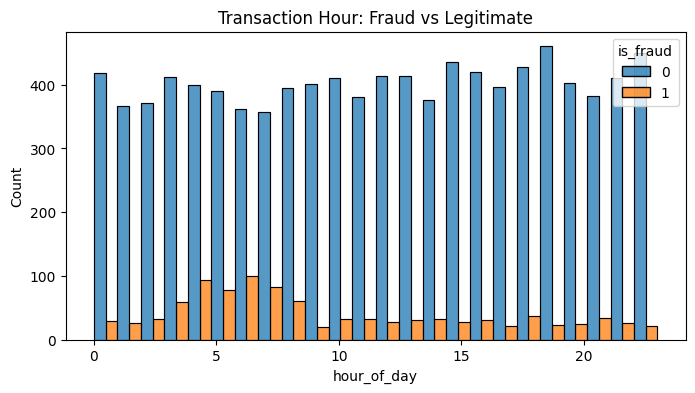

In [38]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='hour_of_day', hue='is_fraud', multiple='dodge', bins=24)
plt.title('Transaction Hour: Fraud vs Legitimate')
plt.show()

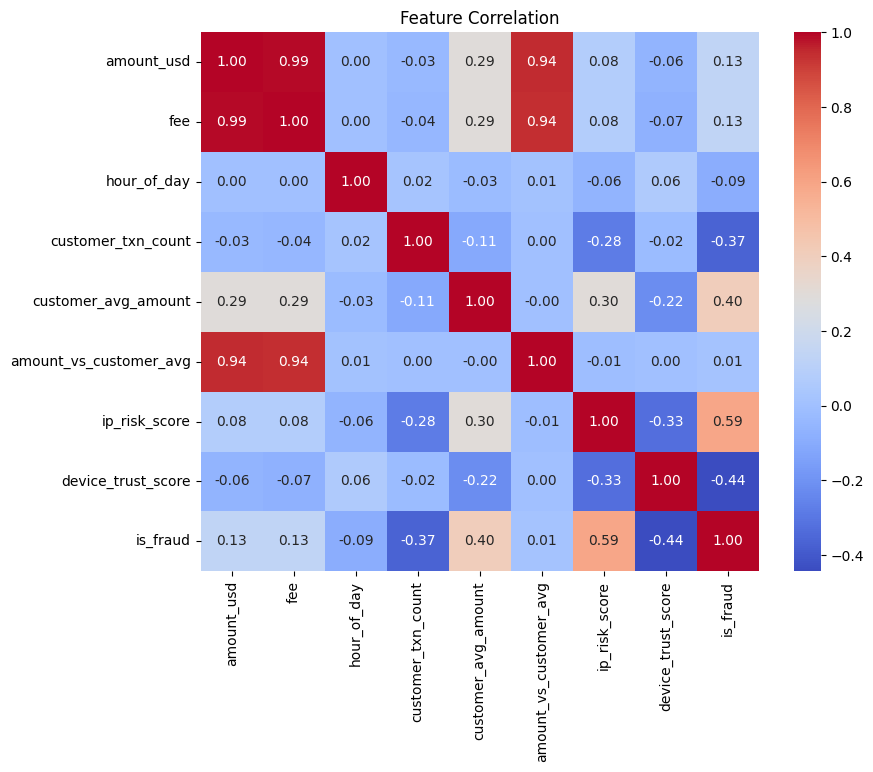

In [ ]:
# correllation heat map
numeric_cols = ['amount_usd', 'fee', 'hour_of_day', 'customer_txn_count',
                'customer_avg_amount', 'amount_vs_customer_avg',
                'ip_risk_score', 'device_trust_score', 'is_fraud']

plt.figure(figsize=(9, 7))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation')
plt.show()

In [40]:
df.to_csv(r'C:\Users\Opeyemi\OneDrive - UNC Kenan-Flagler Business School\Desktop\Data Science\Fraudulent-Transaction-Detection-for-Digital-Money-Transfer/data/features_transactions.csv', index=False)
print('Saved:', df.shape)

Saved: (10622, 41)
